In [19]:
# 1. Import de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Chargement des données
df = pd.read_csv('simulated_poultry_data_2018_2025_enhanced.csv') 

# 3. Inspection initiale
print("=== FORMES ET TYPES ===")
print(f"Shape: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")
print("\n=== INFO DES TYPES ===")
print(df.info())
print("\n=== PREMIERES LIGNES ===")
display(df.head(3))
print("\n=== STATISTIQUES DESCRIPTIVES ===")
display(df.describe())

# 4. Vérification temporelle critique
print("\n=== ANALYSE TEMPORELLE ===")
print(f"Plage de dates: {df['ts'].min()} -> {df['ts'].max()}")
print(f"Fréquence approx: {(pd.to_datetime(df['ts'].max()) - pd.to_datetime(df['ts'].min())) / len(df)}")

# 5. Vérification des capteurs
print("\n=== ANALYSE CAPTEURS ===")
print(f"Nombre de capteurs uniques: {df['device_id'].nunique()}")
print("Répartition par capteur:")
print(df['device_id'].value_counts())

=== FORMES ET TYPES ===
Shape: (70105, 10)
Colonnes: ['ts', 'device_id', 'temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light']

=== INFO DES TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70105 entries, 0 to 70104
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ts         70105 non-null  object 
 1   device_id  70105 non-null  object 
 2   temp       70105 non-null  float64
 3   humidity   70105 non-null  float64
 4   co         70105 non-null  float64
 5   lpg        70105 non-null  float64
 6   smoke      70105 non-null  float64
 7   nh3        70105 non-null  float64
 8   motion     70105 non-null  int64  
 9   light      70105 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 5.3+ MB
None

=== PREMIERES LIGNES ===


,ts,device_id,temp,humidity,co,lpg,smoke,nh3,motion,light
0,2018-01-01 00:00:00,sensor_1,20.68,56.53,0.002264,0.001767,0.001161,0.010267,0,0
1,2018-01-01 01:00:00,sensor_1,20.15,61.93,0.000943,0.000569,0.001181,0.012503,0,0
2,2018-01-01 02:00:00,sensor_1,19.64,64.05,0.003225,0.001192,0.001317,0.012954,1,1



=== STATISTIQUES DESCRIPTIVES ===


,temp,humidity,co,lpg,smoke,nh3,motion,light
count,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000,70105.000000
mean,21.613660,54.976149,0.005897,0.001012,0.001002,0.007207,0.364268,0.692419
std,2.532287,5.854167,0.004398,0.000520,0.000314,0.003910,0.481228,0.461496
min,18.000000,40.000000,0.000000,0.000000,0.000002,0.000000,0.000000,0.000000
25%,19.480000,50.770000,0.002106,0.000662,0.000799,0.004208,0.000000,0.000000
50%,21.500000,54.950000,0.005006,0.001000,0.001001,0.007108,0.000000,1.000000
75%,23.530000,59.240000,0.009095,0.001338,0.001203,0.010002,1.000000,1.000000
max,28.000000,70.000000,0.030000,0.020000,0.012633,0.037127,1.000000,1.000000



=== ANALYSE TEMPORELLE ===
Plage de dates: 2018-01-01 00:00:00 -> 2025-12-31 00:00:00
Fréquence approx: 0 days 00:59:59.948648455

=== ANALYSE CAPTEURS ===
Nombre de capteurs uniques: 1
Répartition par capteur:
device_id
sensor_1    70105
Name: count, dtype: int64


=== ÉTAPE 2 - ANALYSIS TEMPORELLE APPROFONDIE ===
Intervalle moyen: 0 days 01:00:00
Gaps temporels identifiés: 0
Timestamps dupliqués: 0

=== RÉPARTITION PAR ANNÉE ===
year
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8737
Name: count, dtype: int64

=== VALEURS NULLES PAR COLONNE ===
ts           0
device_id    0
temp         0
humidity     0
co           0
lpg          0
smoke        0
nh3          0
motion       0
light        0
year         0
month        0
hour         0
dtype: int64

=== OUTLIERS POTENTIELS (IQR) ===
temp          0
humidity      0
co           24
lpg         294
smoke       528
nh3          86
dtype: int64


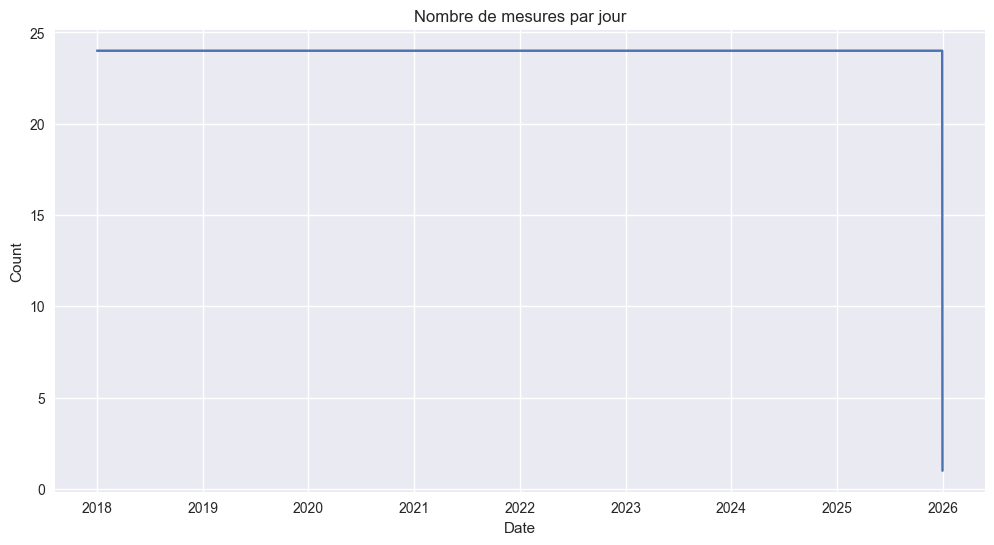

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("=== ÉTAPE 2 - ANALYSIS TEMPORELLE APPROFONDIE ===")

# 1. Conversion du timestamp
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts').reset_index(drop=True)

# 2. Analyse de la régularité temporelle
time_diff = df['ts'].diff()
print(f"Intervalle moyen: {time_diff.mean()}")
print(f"Gaps temporels identifiés: {(time_diff > pd.Timedelta(hours=1.5)).sum()}")

# 3. Vérification des doublons temporels
duplicate_times = df['ts'].duplicated().sum()
print(f"Timestamps dupliqués: {duplicate_times}")

# 4. Analyse de la complétude par année
df['year'] = df['ts'].dt.year
df['month'] = df['ts'].dt.month
df['hour'] = df['ts'].dt.hour

print("\n=== RÉPARTITION PAR ANNÉE ===")
yearly_counts = df['year'].value_counts().sort_index()
print(yearly_counts)

# 5. Vérification des valeurs nulles potentielles
print("\n=== VALEURS NULLES PAR COLONNE ===")
print(df.isnull().sum())

# 6. Détection rapide d'outliers (méthode IQR)
Q1 = df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']].quantile(0.25)
Q3 = df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']] < (Q1 - 1.5 * IQR)) | 
           (df[['temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3']] > (Q3 + 1.5 * IQR))).sum()
print("\n=== OUTLIERS POTENTIELS (IQR) ===")
print(outliers)

# 7. Visualisation rapide de la distribution temporelle
plt.figure(figsize=(12, 6))
df.groupby(df['ts'].dt.date).size().plot()
plt.title('Nombre de mesures par jour')
plt.ylabel('Count')
plt.xlabel('Date')
plt.show()

=== ÉTAPE 3 - FEATURE ENGINEERING TEMPOREL ===
Nouvelles colonnes créées:
Total nouvelles features: 56
Exemples: ['year', 'month', 'hour', 'day_of_week', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1']

Shape après feature engineering: (70105, 66)

Valeurs manquantes après lag:
Total valeurs manquantes: 319


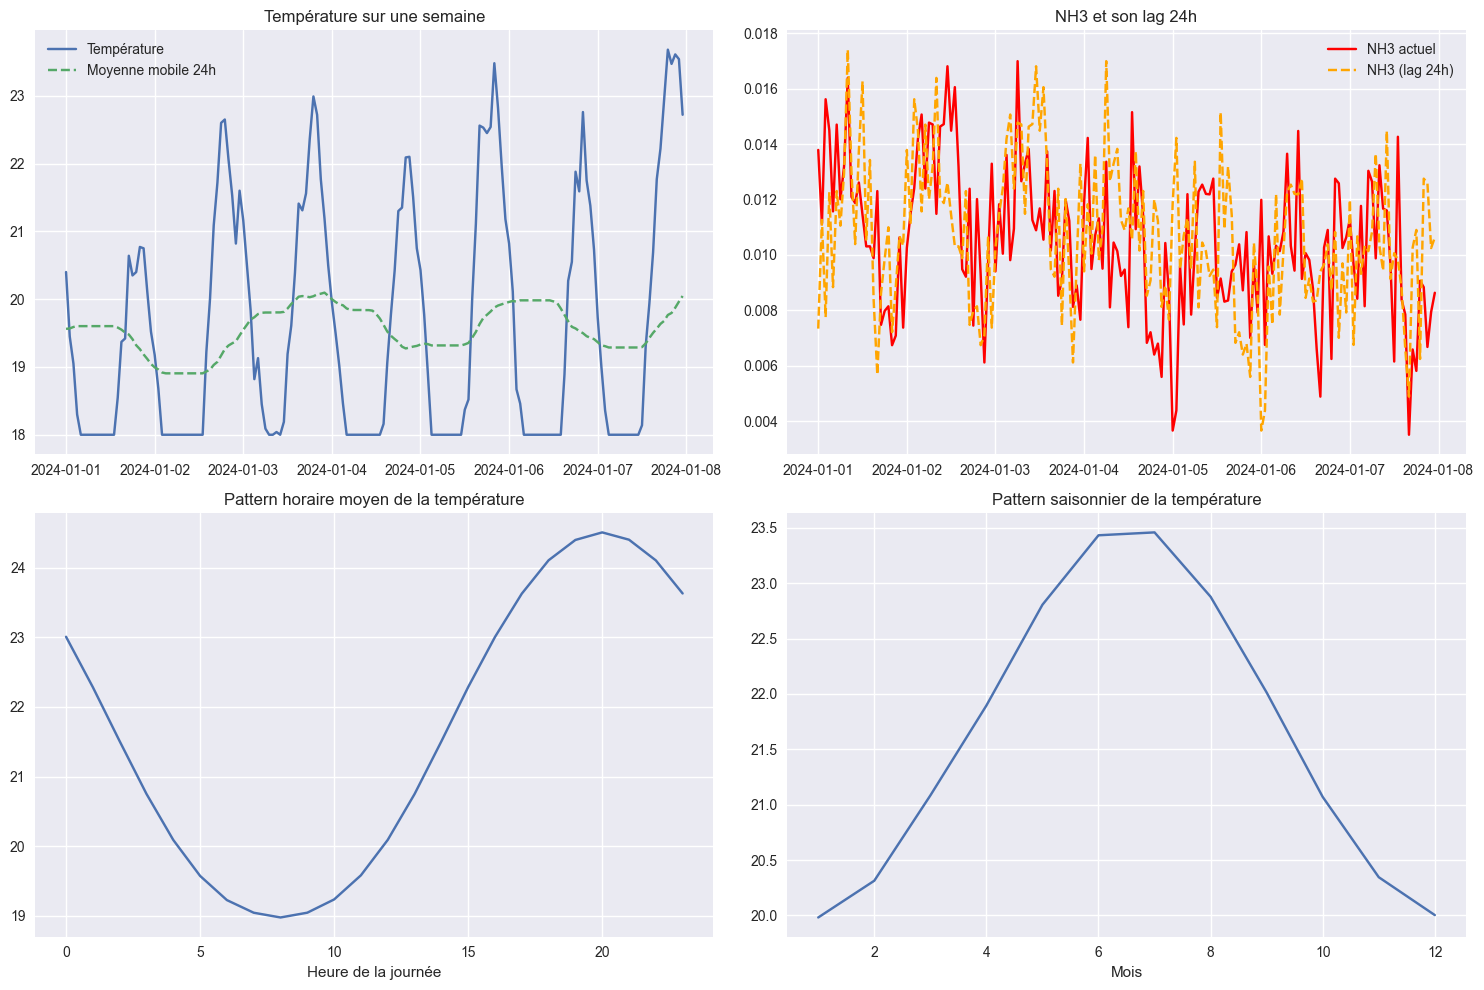


=== PROCHAINES ÉTAPES ===
Les données sont maintenant prêtes pour:
- Split temporel


In [24]:
print("=== ÉTAPE 3 - FEATURE ENGINEERING TEMPOREL ===")

# 1. Features temporelles basiques
df['hour'] = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['month'] = df['ts'].dt.month
df['day_of_year'] = df['ts'].dt.dayofyear

# 2. Encodage cyclique (très important pour les séries temporelles)
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# 3. Features de lag pour les 4 variables cibles
lags = [1, 2, 3, 6, 12, 24]  # lag de 1h à 24h
for lag in lags:
    df[f'temp_lag_{lag}'] = df['temp'].shift(lag)
    df[f'humidity_lag_{lag}'] = df['humidity'].shift(lag)
    df[f'nh3_lag_{lag}'] = df['nh3'].shift(lag)
    df[f'co_lag_{lag}'] = df['co'].shift(lag)

# 4. Features de rolling statistics (moyennes mobiles)
windows = [6, 12, 24]  # 6h, 12h, 24h
for window in windows:
    df[f'temp_rolling_mean_{window}'] = df['temp'].rolling(window=window, min_periods=1).mean()
    df[f'temp_rolling_std_{window}'] = df['temp'].rolling(window=window, min_periods=1).std()
    df[f'humidity_rolling_mean_{window}'] = df['humidity'].rolling(window=window, min_periods=1).mean()

# 5. Features croisées (interactions entre variables)
df['temp_humidity_interaction'] = df['temp'] * df['humidity']
df['nh3_co_ratio'] = df['nh3'] / (df['co'] + 0.001)  # éviter division par zéro

# 6. Target variables pour prédiction multi-horizon
horizons = [1, 6, 24]  # prédire à 1h, 6h et 24h
target_variables = ['temp', 'humidity', 'nh3', 'co']

for horizon in horizons:
    for var in target_variables:
        df[f'{var}_target_{horizon}h'] = df[var].shift(-horizon)

# 7. Vérification des nouvelles features
print("Nouvelles colonnes créées:")
new_features = [col for col in df.columns if col not in ['ts', 'device_id', 'temp', 'humidity', 'co', 'lpg', 'smoke', 'nh3', 'motion', 'light']]
print(f"Total nouvelles features: {len(new_features)}")
print("Exemples:", new_features[:10])

# 8. Analyse des données préparées
print(f"\nShape après feature engineering: {df.shape}")
print("\nValeurs manquantes après lag:")
missing_after_lag = df[new_features].isnull().sum().sum()
print(f"Total valeurs manquantes: {missing_after_lag}")

# 9. Visualisation des relations temporelles
plt.figure(figsize=(15, 10))

# Température sur une semaine exemple
plt.subplot(2, 2, 1)
sample_week = df[(df['ts'] >= '2024-01-01') & (df['ts'] < '2024-01-08')]
plt.plot(sample_week['ts'], sample_week['temp'], label='Température')
plt.plot(sample_week['ts'], sample_week['temp_rolling_mean_24'], label='Moyenne mobile 24h', linestyle='--')
plt.title('Température sur une semaine')
plt.legend()

# NH3 avec lag
plt.subplot(2, 2, 2)
plt.plot(sample_week['ts'], sample_week['nh3'], label='NH3 actuel', color='red')
plt.plot(sample_week['ts'], sample_week['nh3_lag_24'], label='NH3 (lag 24h)', color='orange', linestyle='--')
plt.title('NH3 et son lag 24h')
plt.legend()

# Pattern horaire de la température
plt.subplot(2, 2, 3)
hourly_pattern = df.groupby('hour')['temp'].mean()
plt.plot(hourly_pattern.index, hourly_pattern.values)
plt.title('Pattern horaire moyen de la température')
plt.xlabel('Heure de la journée')

# Pattern saisonnier (mensuel)
plt.subplot(2, 2, 4)
monthly_pattern = df.groupby('month')['temp'].mean()
plt.plot(monthly_pattern.index, monthly_pattern.values)
plt.title('Pattern saisonnier de la température')
plt.xlabel('Mois')

plt.tight_layout()
plt.show()

# 10. Préparation pour les prochaines étapes
print("\n=== PROCHAINES ÉTAPES ===")
print("Les données sont maintenant prêtes pour:")
print("- Split temporel")

In [39]:
print("=== ÉTAPE 4 - FENÊTRAGE TEMPOREL POUR LEARNING ===")

# 1. Nettoyage des NaN (les premières lignes à cause des lags)
df_clean = df.dropna().reset_index(drop=True)
print(f"Shape après suppression des NaN: {df_clean.shape}")
print(f"Pourcentage de données conservées: {len(df_clean)/len(df)*100:.2f}%")

# 2. Définition des paramètres de fenêtrage
WINDOW_SIZE = 24 * 7  # 1 semaine de historique (168 heures)
HORIZON = 24          # Prédire les 24 prochaines heures
STRIDE = 1            # Pas de 1 heure entre les fenêtres

print(f"\nParamètres de fenêtrage:")
print(f"Window size (historique): {WINDOW_SIZE} heures")
print(f"Horizon (prédiction): {HORIZON} heures")
print(f"Stride: {STRIDE} heure(s)")

# 3. Sélection des features et targets
feature_columns = [col for col in df_clean.columns if col not in [
    'ts', 'device_id', 'year', 'month', 'hour', 'day_of_week', 'day_of_year'  # On garde les versions cycliques
] and not col.endswith('_target_1h') and not col.endswith('_target_6h') and not col.endswith('_target_24h')]

target_columns = ['temp_target_1h', 'temp_target_6h', 'temp_target_24h', 
                  'humidity_target_1h', 'humidity_target_6h', 'humidity_target_24h',
                  'nh3_target_1h', 'nh3_target_6h', 'nh3_target_24h',
                  'co_target_1h', 'co_target_6h', 'co_target_24h']

print(f"\nNombre de features: {len(feature_columns)}")
print(f"Nombre de targets: {len(target_columns)}")

# 4. Fonction de fenêtrage adaptée à notre cas
def create_sequential_windows(features, targets, window_size, horizon, stride):
    """
    Crée des fenêtres séquentielles pour l'apprentissage supervisé
    """
    X, y = [], []
    n_samples = len(features)
    
    for start_idx in range(0, n_samples - window_size - horizon + 1, stride):
        end_idx = start_idx + window_size
        target_idx = end_idx + horizon - 1  # On prend le dernier point de l'horizon
        
        # Features: fenêtre historique
        window_features = features[start_idx:end_idx]
        
        # Targets: valeurs à l'horizon pour les 4 variables
        window_targets = targets.iloc[target_idx][[
            'temp_target_1h', 'humidity_target_1h', 'nh3_target_1h', 'co_target_1h',
            'temp_target_6h', 'humidity_target_6h', 'nh3_target_6h', 'co_target_6h', 
            'temp_target_24h', 'humidity_target_24h', 'nh3_target_24h', 'co_target_24h'
        ]].values
        
        X.append(window_features)
        y.append(window_targets)
    
    return np.array(X), np.array(y)

# 5. Préparation des données pour le fenêtrage
features_data = df_clean[feature_columns].values
targets_data = df_clean[target_columns]

# 6. Création des fenêtres
X, y = create_sequential_windows(features_data, targets_data, WINDOW_SIZE, HORIZON, STRIDE)

print(f"\n=== RÉSULTATS DU FENÊTRAGE ===")
print(f"X shape: {X.shape}")  # (échantillons, fenêtre, features)
print(f"y shape: {y.shape}")  # (échantillons, 12 targets)

# 7. Split temporel (CRITIQUE pour les séries temporelles)
total_samples = len(X)
train_size = int(0.7 * total_samples)  # 70% train
val_size = int(0.15 * total_samples)   # 15% validation

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"\n=== SPLIT TEMPOREL ===")
print(f"Train: {len(X_train)} échantillons ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val)} échantillons ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} échantillons ({len(X_test)/len(X)*100:.1f}%)")

# 8. Normalisation des données (par feature sur l'ensemble d'entraînement)
from sklearn.preprocessing import StandardScaler

# Scalers pour les features
feature_scalers = {}
X_train_scaled = np.zeros_like(X_train)
X_val_scaled = np.zeros_like(X_val)
X_test_scaled = np.zeros_like(X_test)

# Normalisation par feature
for feature_idx in range(X_train.shape[2]):
    scaler = StandardScaler()
    # On reshape pour avoir (samples * window_size, 1)
    feature_data = X_train[:, :, feature_idx].reshape(-1, 1)
    scaler.fit(feature_data)
    
    # Application à tous les sets
    X_train_scaled[:, :, feature_idx] = scaler.transform(
        X_train[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_train.shape[0], X_train.shape[1])
    
    X_val_scaled[:, :, feature_idx] = scaler.transform(
        X_val[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_val.shape[0], X_val.shape[1])
    
    X_test_scaled[:, :, feature_idx] = scaler.transform(
        X_test[:, :, feature_idx].reshape(-1, 1)
    ).reshape(X_test.shape[0], X_test.shape[1])
    
    feature_scalers[feature_idx] = scaler

print(f"\n=== NORMALISATION TERMINÉE ===")
print(f"Données d'entraînement scaled - Mean: {X_train_scaled.mean():.3f}, Std: {X_train_scaled.std():.3f}")

# 9. Vérification de la distribution temporelle des splits
split_dates = df_clean['ts'].iloc[WINDOW_SIZE:WINDOW_SIZE+len(X)]  # Dates correspondant aux fenêtres

print(f"\n=== PÉRIODES DES SPLITS ===")
print(f"Train: {split_dates.iloc[0].strftime('%Y-%m-%d')} -> {split_dates.iloc[train_size-1].strftime('%Y-%m-%d')}")
print(f"Val: {split_dates.iloc[train_size].strftime('%Y-%m-%d')} -> {split_dates.iloc[train_size+val_size-1].strftime('%Y-%m-%d')}")
print(f"Test: {split_dates.iloc[train_size+val_size].strftime('%Y-%m-%d')} -> {split_dates.iloc[-1].strftime('%Y-%m-%d')}")

# 10. Sauvegarde des métadonnées pour la reproduction
metadata = {
    'window_size': WINDOW_SIZE,
    'horizon': HORIZON,
    'stride': STRIDE,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'input_shape': X_train_scaled.shape[1:],
    'output_shape': y_train.shape[1]
}

print(f"\n=== MÉTADONNÉES ===")
for key, value in metadata.items():
    if key not in ['feature_columns', 'target_columns']:
        print(f"{key}: {value}")

print(f"\nShape d'entrée du modèle: {metadata['input_shape']}")
print(f"Shape de sortie du modèle: {metadata['output_shape']}")

=== ÉTAPE 4 - FENÊTRAGE TEMPOREL POUR LEARNING ===
Shape après suppression des NaN: (70057, 66)
Pourcentage de données conservées: 99.93%

Paramètres de fenêtrage:
Window size (historique): 168 heures
Horizon (prédiction): 24 heures
Stride: 1 heure(s)

Nombre de features: 47
Nombre de targets: 12


MemoryError: Unable to allocate 4.11 GiB for an array with shape (69866, 168, 47) and data type float64

In [3]:
import psutil

# Info système
ram = psutil.virtual_memory()
total = ram.total / (1024 ** 3)       # Convertir en Go
used = ram.used / (1024 ** 3)
available = ram.available / (1024 ** 3)

print(f"💾 Mémoire totale : {total:.2f} Go")
print(f"📊 Mémoire utilisée : {used:.2f} Go")
print(f"✅ Mémoire disponible : {available:.2f} Go")


💾 Mémoire totale : 7.73 Go
📊 Mémoire utilisée : 6.72 Go
✅ Mémoire disponible : 1.01 Go
